<a href="https://colab.research.google.com/github/SHRESHTH121/HandsOnMachineLearning/blob/main/LearningCurves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [14]:
def plot_learning_curves(model, X, y, start_size=5):

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    train_rmse = []
    val_rmse = []
    train_sizes = []

    # Train on increasing amounts of data
    for i in range(start_size, len(X_train) + 1):

        # Fit model on first i samples
        model.fit(X_train[:i], y_train[:i])

        # Training predictions
        y_train_pred = model.predict(X_train[:i])

        # Validation predictions
        y_val_pred = model.predict(X_val)

        # RMSE
        train_rmse.append(
            np.sqrt(mean_squared_error(y_train[:i], y_train_pred))
        )

        val_rmse.append(
            np.sqrt(mean_squared_error(y_val, y_val_pred))
        )

        train_sizes.append(i)

    # Plot
    plt.figure(figsize=(8,5))

    plt.plot(
        train_sizes,
        train_rmse,
        "r-",
        linewidth=2,
        label="Training RMSE"
    )

    plt.plot(
        train_sizes,
        val_rmse,
        "b-",
        linewidth=2,
        label="Validation RMSE"
    )

    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title("Learning Curves")
    plt.legend()
    plt.grid(True)

    plt.show()

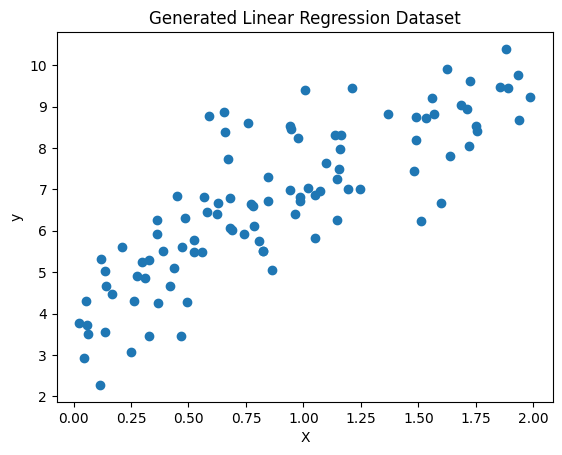

In [3]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Linear Regression Dataset')
plt.show()

Intercept: 4.22
Coefficient: 2.82


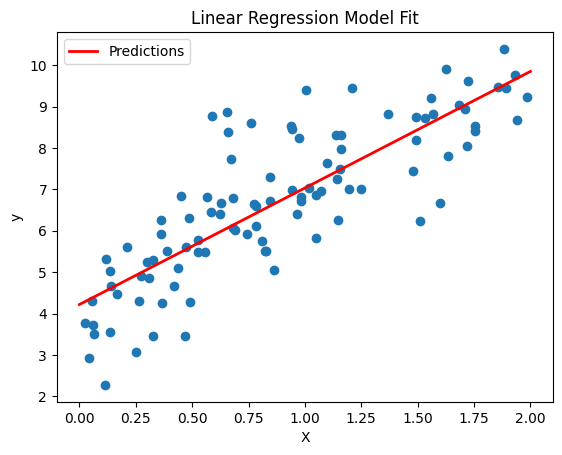

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f"Intercept: {lin_reg.intercept_[0]:.2f}")
print(f"Coefficient: {lin_reg.coef_[0][0]:.2f}")

X_new = np.array([[0], [2]])
y_predict = lin_reg.predict(X_new)

plt.scatter(X, y)
plt.plot(X_new, y_predict, 'r-', linewidth=2, label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Model Fit')
plt.legend()
plt.show()

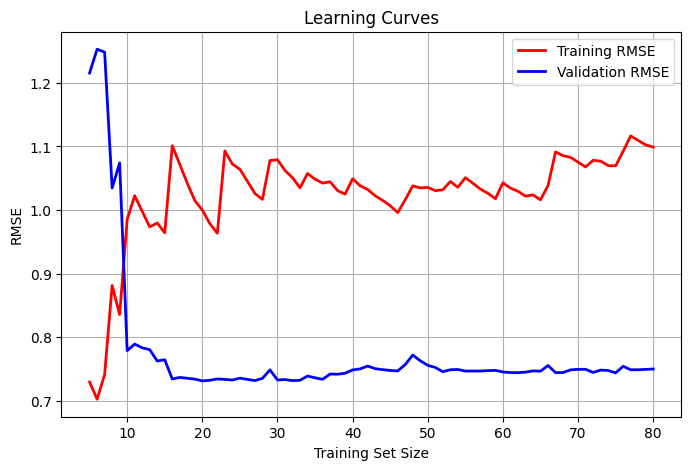

In [15]:
plot_learning_curves(LinearRegression(),X,y)